## Ensembles for Customer Satisfaction Prediction

KATE expects your code to define variables with specific names that correspond to certain things we are interested in.

KATE will run your notebook from top to bottom and check the latest value of those variables, so make sure you don't overwrite them.

* Remember to uncomment the line assigning the variable to your answer and don't change the variable or function names.
* Use copies of the original or previous DataFrames to make sure you do not overwrite them by mistake.

You will find instructions below about how to define each variable.

Once you're happy with your code, upload your notebook to KATE to check your feedback.

Businesses can improve their services by tailoring them to individual customers. One important factor is knowing when customers are dissatisfied. Based on their records, one can use machine learning tools to make predictions about which customers are more at risk of being dissatisfied than others. Such predictions allow for individualised actions that may help retain customers and will improve quality.

In this assignment, we will build a prediction model for bank account owners' satisfaction. The record includes more than 300 features for each client, including variables related to their balance and which banking operations they have performed. Many of these variables are sparse; some numerical, some categorical. 

Ensemble methods based on decision trees, such as random forests and boosting algorithms, have been very successful in modeling such heterogeneous tabular data. To learn how these models work, you will implement them step-by-step, and see how the performance of your predictions improve.

### Load the data

Load the data in `data/train_data.csv` with `pandas`. Inspect its content with `.head()`, `.shape` and other methods of your choice.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/train_data.csv')
df.head()

,Unnamed: 0,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,47739,2,29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,46565.040000,0
1,4212,2,38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90736.770000,0
2,48967,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016,0
3,11077,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,172107.720000,0
4,17475,2,26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67983.570000,0


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66020 entries, 0 to 66019
Columns: 371 entries, Unnamed: 0 to TARGET
dtypes: float64(111), int64(260)
memory usage: 186.9 MB


In [49]:
df.shape

(66020, 371)

In [50]:
df.describe()

,Unnamed: 0,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
count,66020.000000,66020.000000,66020.000000,66020.000000,66020.000000,66020.000000,66020.000000,66020.000000,66020.000000,66020.000000,...,66020.000000,66020.000000,66020.000000,66020.000000,66020.000000,66020.000000,66020.000000,66020.000000,6.602000e+04,66020.000000
mean,37990.882036,-1542.299864,33.167161,87.535996,71.738457,118.568268,3.643963,6.377262,0.434144,0.546049,...,7.403436,1.388534,11.638854,8.328190,24.702141,1.846955,63.917692,50.587842,1.173635e+05,0.039564
std,21928.070588,39276.303887,12.916117,1672.551952,339.606395,544.623234,94.786184,152.885670,32.014042,35.414060,...,450.137774,119.233430,785.872340,537.365789,1224.664797,153.817000,2943.553947,2457.194182,1.872566e+05,0.194933
min,0.000000,-999999.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.163750e+03,0.000000
25%,18999.750000,2.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.784343e+04,0.000000
50%,37992.500000,2.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.063470e+05,0.000000
75%,56926.250000,2.000000,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.187278e+05,0.000000
max,76018.000000,238.000000,105.000000,210000.000000,12888.030000,21024.810000,8237.820000,11073.570000,6600.000000,6600.000000,...,50003.880000,20385.720000,138831.630000,91778.730000,126006.180000,24650.010000,397884.300000,397884.300000,2.203474e+07,1.000000


In [51]:
df.dtypes.value_counts()

int64      260
float64    111
Name: count, dtype: int64

#### Target variable

The last column, named `TARGET`, is the variable to be predicted. `TARGET=1` represents a dissatisfied customer. Inspect the target column with `.value_counts()`. 

What is the proportion of dissatisfied customers? Is the dataset balanced or imbalanced?

In [52]:
df['TARGET'].value_counts()  # imbalanced dataset

TARGET
0    63408
1     2612
Name: count, dtype: int64

In [53]:
df['TARGET'].mean()

0.039563768554983336

Separate the data into features `X` and target `y`. Split the data into `_train` and `_val` sets, using the default sklearn ratios and stratifying on `y` to keep the same level of imbalance.

*Hint: you may use `train_test_split()` for stratified splits.*

In [54]:
from sklearn.model_selection import train_test_split

X = df.drop(['TARGET', 'Unnamed: 0'], axis=1)
y = df['TARGET']

X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, random_state=42)
# stratify to ensure both train and val sets to have the same proportion of dissatisfied customers

### Basic modelling pipeline

Implement a basic modelling pipeline for a Decision Tree Classifier, fitting the training data and printing the training and validation accuracy.

In [55]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)

print(f"Training accuracy: {dtc.score(X_train, y_train):.4f}")
print(f"Validation accuracy: {dtc.score(X_val, y_val):.4f}")


Training accuracy: 0.9959
Validation accuracy: 0.9287


Note that the accuracy score is quite high, even for this very simple model. Take a moment to think why this high score is not that significant.

#### ROC curve metric

Change your scoring metric to `roc_auc_score`, which calculates the area below the ROC curve of your **prediction probabilities**, instead of using the binary prediction decisions.

*Hint: `model.predict_proba(X)` will return the probabilities for `y = 0` and `y = 1`, slice this to only return the `y = 1` predictions. 

In [56]:
from sklearn.metrics import roc_auc_score

# ROC = Receiver Operating Characteristics - plots TPR vs FPR at every classification threshold
# AUC = Area Under the Curve - a single number (0 or 1) summarizing the ROC curve. 1.0 - perfect, 0.5 - random guessing.
# Together, ROC-AUC tells us how well the model separates the two classess across all possible thresholds

y_train_prob = dtc.predict_proba(X_train)[:, 1]
y_val_prob = dtc.predict_proba(X_val)[:,1]

print(f"Training AUC: {roc_auc_score(y_train, y_train_prob):.4f}")                                                                 
print(f"Validation AUC: {roc_auc_score(y_val, y_val_prob):.4f}")     

# AUC is a better metric than accuracy for imbalanced datasets
# accuracy can look high by just predicting the majority class       
                                                                                          

Training AUC: 0.9993
Validation AUC: 0.5664


#### Baseline score for random predictions

Calculate the ROC AUC for random uniform prediction probabilities. 

Is the Decision Tree better? Based on the training and validation scores, what is the problem with the Decision Tree model?

*Hint: You can use `np.random.uniform` to create an array of random numbers under 1.*

In [57]:
np.random.seed(42)
y_random = np.random.uniform(0, 1, len(y_val))

print(f"Random AUC: {roc_auc_score(y_val, y_random):.4f}")

Random AUC: 0.4997


Create a function named `test_model(model, X_train, y_train, X_val, y_val)` that performs the basic prediction pipeline, receiving as argument the model and data, fitting the training data, and returning the training and validation `roc_auc_score`. Check that it works with the Decision Tree model.

In [58]:
def test_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_train_prob = model.predict_proba(X_train)[:,1]
    y_val_prob = model.predict_proba(X_val)[:,1]
    
    # [:, 1] selects all rows (:) from column 1 - probability of being dissatisfied (TARGET=1) - what we care about.         
    # We don't need column 0 since the two columns always sum to 1.       
    
    return roc_auc_score(y_train, y_train_prob), roc_auc_score(y_val, y_val_prob)

In [59]:
train_auc, val_auc = test_model(dtc, X_train, y_train, X_val, y_val)                                                              
print(f"Training AUC: {train_auc:.4f}")                                                                                            
print(f"Validation AUC: {val_auc:.4f}")    

Training AUC: 0.9993
Validation AUC: 0.5664


## Optimising decision trees 

Optimise your model by changing the `max_depth` hyperparameter. Iterate through and calculate the training and validation scores for depths of `[1,2,5,10,20,50]`. Which depth has the best performance? Remember that we want a model that performs well on both the training and validation datasets. 

Depth  1: Train AUC = 0.6796, Val AUC = 0.6827
Depth  2: Train AUC = 0.7753, Val AUC = 0.7752
Depth  5: Train AUC = 0.8277, Val AUC = 0.8187
Depth 10: Train AUC = 0.8630, Val AUC = 0.8036
Depth 20: Train AUC = 0.9614, Val AUC = 0.6590
Depth 50: Train AUC = 0.9993, Val AUC = 0.5692


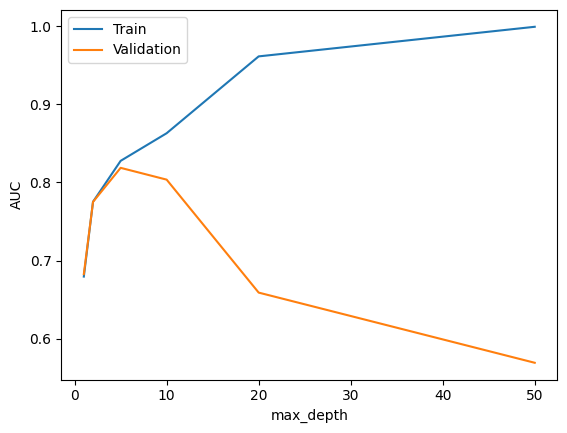

In [60]:
depths = [1, 2, 5, 10, 20, 50]                                                                                                     
train_aucs = []                                                                                                                    
val_aucs = []  

for d in depths:                                                                                                                   
    model = DecisionTreeClassifier(max_depth=d, random_state=42)                                                                   
    train_auc, val_auc = test_model(model, X_train, y_train, X_val, y_val)                                                         
    train_aucs.append(train_auc)                                                                                                   
    val_aucs.append(val_auc)                                                                                                       
    print(f"Depth {d:2d}: Train AUC = {train_auc:.4f}, Val AUC = {val_auc:.4f}")                                                   
                                                                                                                                     
plt.plot(depths, train_aucs, label='Train')                                                                                        
plt.plot(depths, val_aucs, label='Validation')                                                                                     
plt.xlabel('max_depth')                                                                                                            
plt.ylabel('AUC')                                                                                                                  
plt.legend()   

# Low depth = underfitting (both scores low)
# High depth = overfitting (train high, val drops)
# The best depth is where validation AUC peaks

To evaluate your models, we will test your data on an unseen testing set. Load the test at `data/test_data.csv`.

In [61]:
test_data = pd.read_csv('data/test_data.csv')

 Calculate the prediction probabilities for the `test_data` using the best Decision Tree depth, saving them in a variable named `dtc_preds`. `dtc_preds` should be an numpy array containing the probabilities for `y = 1` only.

In [62]:
best_dtc = DecisionTreeClassifier(max_depth=5, random_state=42)                                                                    
best_dtc.fit(X_train, y_train)                                                                                                     
dtc_preds = best_dtc.predict_proba(test_data)[:, 1] 

### Bagging

While decision trees are prone to overfitting, their ensemble can be a powerful predictor. A bagging ensemble of decision trees uses the average prediction of multiple decision trees base models, that have each been trained with on a different set of data samples. This resampling processes is known as Bootstraping. (The name Bagging comes from Bootstrap + Aggregation, meaning bootstrap your data and then aggregate your model outputs.)

You will create a Bagging model class, named `myBagging`, filling in the class structure below.

The `.fit()` method should fit each base model with a bootstrap sample of the data (with replacement), with data size proportional by the hyperparameter `subsample`. That is, if `subsample=0.5`, each base model should get half the total number of samples.

The `.predict_proba()` method should estimate and average the prediction probabilities of the base models.

*Hint: You can use the `resample()` function for creating bootstrap samples.*

class myBagging:
    def __init__(self, base_models, subsample = 1.):
        self.n_models = len(base_models)
        self.base_models = base_models
        self.subsample = subsample
        
    def fit(self, X, y):
        '''Loop over base models, generate a bootstrap sample of the data with 'resample()',
           and fit them to the data.
           
           To access the variables inside the myBagging class, use the 'self.' prefix, 
           i.e. self.base_models, self.n_models and self.subsample
        '''
        from sklearn.utils import resample
        pass
    
    def predict_proba(self, X):
        '''Return the ensemble predictions, given by the average prediction probability over base models.
           It should be an array with the length of the dataset.'''
        pass  

In [63]:
from sklearn.utils import resample
                                                                                                                                  
class myBagging:                                                                                                                   
    def __init__(self, base_models, subsample=1.):                                                                                 
        self.n_models = len(base_models)                                                                                           
        self.base_models = base_models                                                                                             
        self.subsample = subsample                                                                                                 
                                                                                                                                     
    def fit(self, X, y):                                                                                                           
        for model in self.base_models:                                                                                             
            n_samples = int(len(X) * self.subsample)                                                                               
            X_boot, y_boot = resample(X, y, n_samples=n_samples)                                                                   
            model.fit(X_boot, y_boot)                                                                                              
                                                                                                                                     
    def predict_proba(self, X):                                                                                                    
        probs = np.array([model.predict_proba(X)[:, 1] for model in self.base_models])                                             
        return np.column_stack([1 - probs.mean(axis=0), probs.mean(axis=0)]) 

Run and score a Bagging ensemble, with 10 decision trees as base learners, with maximum depth 10 and subsample 0.5. Use your `myBagging` class and `test_model()`.

In [64]:
base_models = [DecisionTreeClassifier(max_depth=10, random_state=i) for i in range(10)]                                            
bagging = myBagging(base_models, subsample=0.5)                                                                                    
train_auc, val_auc = test_model(bagging, X_train, y_train, X_val, y_val)                                                           

print(f"Training AUC: {train_auc:.4f}")                                                                                            
print(f"Validation AUC: {val_auc:.4f}") 

# The validation AUC should improve over the single decision tree
# Bagging reduces overfitting by averaging out the variance of individual trees

Training AUC: 0.8859
Validation AUC: 0.8253


### Sklearn comparison

For comparison, run the below cell to see how the `sklearn` implementation, `BaggingClassifier` does. 

Is there much of a difference? Why could that be?

In [65]:
from sklearn.ensemble import BaggingClassifier

test_model(BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=10), 
    n_estimators=10,
    max_samples=0.5
), X_train, y_train, X_val, y_val)

(0.8901502212206144, 0.8253011006480696)

### Random Forests

Random Forests are bagged ensembles of decision trees in which, at each node split during training, only a fraction of the features are considered for the optimal split (e.g. for optimal Gini gain).

Run and score a Random Forest version of your `myBagging` classifier, by changing the `max_features` parameter inside the base learner.

In [66]:
base_models = [DecisionTreeClassifier(max_depth=10, max_features='sqrt', random_state=i) for i in range(10)]
rf = myBagging(base_models, subsample=0.5)                                                                                         
train_auc, val_auc = test_model(rf, X_train, y_train, X_val, y_val)                                                                

print(f"Training AUC: {train_auc:.4f}")                                                                                            
print(f"Validation AUC: {val_auc:.4f}")                                                                                            
                                                                                                                                     
# max_features='sqrt' means each split only considers √(n_features) random features
# This adds more diversity between trees, further reducing overfitting compared to plain bagging.  

Training AUC: 0.8284
Validation AUC: 0.7810


### Sklearn comparison

For comparison, run and score the `sklearn` implementation, `RandomForestClassifier`.

Is there much of a difference? Why could that be?

In [67]:
from sklearn.ensemble import RandomForestClassifier                                                                                
                                                                                                                                     
rf_sklearn = RandomForestClassifier(n_estimators=10, max_depth=10, max_samples=0.5, random_state=42)                               
train_auc, val_auc = test_model(rf_sklearn, X_train, y_train, X_val, y_val)                                                        

print(f"Training AUC: {train_auc:.4f}")                                                                                            
print(f"Validation AUC: {val_auc:.4f}")       

# Results should be similar

Training AUC: 0.8471
Validation AUC: 0.8045


### Optimise your Random Forest

Optimise your Random Forest hyperparameters, both for the myBagging class and for the base decision trees. 

Calculate the prediction probabilities for the `test_data` using your best random forest, saving them in a variable named `rf_preds`. Like before `rf_preds` should be an numpy array containing the probabilities for `y = 1` only.


In [68]:
#  Can experiment with different values to find the best combo:                                                                   
#  - n_estimators (list length): 10, 20, 50, 100                                                                                      
#  - max_depth: 5, 10, 15, 20                                                                                                         
#  - max_features: 'sqrt', 'log2', 0.5                                                                                                
#  - subsample: 0.5, 0.8, 1.0         

# I will stick to 4, otherwise it is too much
configs = [                                                                                                                        
    (20, 10, 'sqrt', 0.8),                                                                                                         
    (50, 10, 'sqrt', 0.8),                                                                                                         
    (20, 15, 'sqrt', 0.5),                                                                                                         
    (50, 15, 'log2', 0.8),                                                                                                         
]                                                                                                                                  
                                                                                                                                     
best_val_auc = 0                                                                                                                   
best_params = {}                                                                                                                   
                                                                                                                                     
for n_est, depth, feat, sub in configs:                                                                                            
    base_models = [DecisionTreeClassifier(max_depth=depth, max_features=feat, random_state=i) for i in range(n_est)]               
    model = myBagging(base_models, subsample=sub)                                                                                  
    train_auc, val_auc = test_model(model, X_train, y_train, X_val, y_val)                                                         
    print(f"n={n_est}, depth={depth}, feat={feat}, sub={sub} -> Train: {train_auc:.4f}, Val: {val_auc:.4f}")                       
                                                                                                                                     
    if val_auc > best_val_auc:                                                                                                     
        best_val_auc = val_auc                                                                                                     
        best_params = {'n_estimators': n_est, 'max_depth': depth, 'max_features': feat, 'subsample': sub}                          
                                                                                                                                     
print(f"\nBest: {best_params}, Val AUC: {best_val_auc:.4f}")       

n=20, depth=10, feat=sqrt, sub=0.8 -> Train: 0.8590, Val: 0.8056
n=50, depth=10, feat=sqrt, sub=0.8 -> Train: 0.8682, Val: 0.8067
n=20, depth=15, feat=sqrt, sub=0.5 -> Train: 0.8963, Val: 0.8007
n=50, depth=15, feat=log2, sub=0.8 -> Train: 0.8802, Val: 0.7964

Best: {'n_estimators': 50, 'max_depth': 10, 'max_features': 'sqrt', 'subsample': 0.8}, Val AUC: 0.8067


In [70]:
base_models = [DecisionTreeClassifier(max_depth=10, max_features='sqrt', random_state=i) for i in range(50)]                       
best_rf = myBagging(base_models, subsample=0.8)                                                                                    
best_rf.fit(X_train, y_train)                                                                                                      
rf_preds = best_rf.predict_proba(test_data)[:, 1]    

Note that including more decision trees improve performance but increases the computational cost of training linearly. The `max_depth` and `max_features` arguments can heavily cut the training time, by reducing the tree size and number of features considered at each split.

## Gradient Boosting

We will now implement a more sophisticated ensemble, Gradient Boosting, in which the base models are trained sequentially. Each new base model predicts what previous base models missed. 

As gradient boosting requires a continuous gradient, it can only use regression models for the base learner. 

For this exercise, we will perform regression directly on the 0-1 class labels, and treat the raw outputs as probabilities. 

We will try to setup the base models to optimise the MSE loss function against the class-labels, for which the gradient becomes simply the residual errors. 

When applied to probabilities, the MSE is known as the Brier score. 

Whilst performing this exercise, have a think about whether this is a robust approach. 

If not, what would you change either to your base-learners, meta-algorithm, or evaluation metrics to make this more robust?

In the below structure, fill the `.fit()` and `.predict_proba()` functions. When returning probabilities remember that you will need to return an array containing the probabilities for `y = 0` and `y = 1`. 

class myGradientBoosting:
    
    def __init__(self, base_models, learning_rate=0.5):
        self.n_models = len(base_models)
        self.models = base_models
        self.learning_rate = learning_rate
    
    def fit(self, x, y):
        ''' The `.fit()` function should loop over each base model 
         fitting it to the residual of the ensemble predictions so far, for the MSE loss:
         
         predictions = 0
         for each base model:
             residual = y - predictions   
             fit base model and make new predictions
             predictions = predictions + learning_rate * new_prediction 
        '''
        pass
       
    def predict_proba(self, x):
        ''' Generate the ensemble prediction, by looping over each base model.
            Get their predictions and sum them, scaled by the learning rate.
        
            Trick: Regressor models return only one prediction (instead of two probabilities in the Classifiers).
                   To make your class compatible with test_model(), you need to output the probabilities for both
                   y = 0 and y = 1, this can be done using np.array([1-probs, probs]).T'''
        pass
        


In [36]:
from sklearn.tree import DecisionTreeRegressor
                                                                                                                                  
class myGradientBoosting:                                                                                                                                                                                                                                        
    def __init__(self, base_models, learning_rate=0.5):                                                                            
        self.n_models = len(base_models)                                                                                           
        self.models = base_models                                                                                                  
        self.learning_rate = learning_rate                                                                                         
                                                                                                                                     
    def fit(self, x, y):                                                                                                           
        predictions = np.zeros(len(y))                                                                                             
        for model in self.models:                                                                                                  
            residual = y - predictions                                                                                             
            model.fit(x, residual)                                                                                                 
            predictions = predictions + self.learning_rate * model.predict(x)                                                      
                                                                                                                                     
    def predict_proba(self, x):                                                                                                    
        probs = np.zeros(len(x))                                                                                                   
        for model in self.models:                                                                                                  
            probs = probs + self.learning_rate * model.predict(x)                                                                  
        return np.array([1 - probs, probs]).T 

Run and score a Gradient Boosting model, with 20 regression decision trees as your base learners, with maximum depth 5, maximum feature 0.5, and learning rate 0.5. Use your `myGradientBoosting` class and `test_model()`. 

In [37]:
base_models = [DecisionTreeRegressor(max_depth=5, max_features=0.5, random_state=i) for i in range(20)]                            
gb = myGradientBoosting(base_models, learning_rate=0.5)                                                                            
train_auc, val_auc = test_model(gb, X_train, y_train, X_val, y_val)                                                                

print(f"Training AUC: {train_auc:.4f}")                                                                                            
print(f"Validation AUC: {val_auc:.4f}")   

Training AUC: 0.8691
Validation AUC: 0.8241


### Sklearn comparison

For comparison, run and score the `sklearn` implementation, `GradientBoostingClassifier` in the cell below.

In [39]:
from sklearn.ensemble import GradientBoostingClassifier                                                                            
                                                                                                                                     
gb_sklearn = GradientBoostingClassifier(n_estimators=20, max_depth=5, max_features=0.5, learning_rate=0.5, random_state=42)        
train_auc, val_auc = test_model(gb_sklearn, X_train, y_train, X_val, y_val)                                                        

print(f"Training AUC: {train_auc:.4f}")                                                                                            
print(f"Validation AUC: {val_auc:.4f}")                                                                                                                               

Training AUC: 0.8666
Validation AUC: 0.8242


### Optimise your Gradient Boosting 

Optimise your myGradientBoosting and decision tree hyperparameters.

Calculate the prediction probabilities for the `test_data` using your best gradient boosting model saving them in a variable named `gb_preds`. Like before `gb_preds` should be an numpy array containing the probabilities for `y = 1` only.


In [40]:
# Same approach as before - 4 combinations
configs = [                                                                                                                        
    (50, 3, 0.5, 0.1),                                                                                                             
    (50, 5, 0.5, 0.1),                                                                                                             
    (100, 3, 0.5, 0.1),                                                                                                            
     (100, 5, 0.5, 0.05),                                                                                                           
]                                                                                                                                  
                                                                                                                                     
best_val_auc = 0                                                                                                                   
best_params = {}                                                                                                                   
                                                                                                                                     
for n_est, depth, feat, lr in configs:                                                                                             
    base_models = [DecisionTreeRegressor(max_depth=depth, max_features=feat, random_state=i) for i in range(n_est)]                
    model = myGradientBoosting(base_models, learning_rate=lr)                                                                      
    train_auc, val_auc = test_model(model, X_train, y_train, X_val, y_val)                                                         
    print(f"n={n_est}, depth={depth}, feat={feat}, lr={lr} -> Train: {train_auc:.4f}, Val: {val_auc:.4f}")                         
                                                                                                                                     
    if val_auc > best_val_auc:                                                                                                     
        best_val_auc = val_auc                                                                                                     
        best_params = {'n_estimators': n_est, 'max_depth': depth, 'max_features': feat, 'learning_rate': lr}                       
                                                                                                                                     
print(f"\nBest: {best_params}, Val AUC: {best_val_auc:.4f}")   

n=50, depth=3, feat=0.5, lr=0.1 -> Train: 0.8474, Val: 0.8313
n=50, depth=5, feat=0.5, lr=0.1 -> Train: 0.8733, Val: 0.8358
n=100, depth=3, feat=0.5, lr=0.1 -> Train: 0.8556, Val: 0.8322
n=100, depth=5, feat=0.5, lr=0.05 -> Train: 0.8737, Val: 0.8347

Best: {'n_estimators': 50, 'max_depth': 5, 'max_features': 0.5, 'learning_rate': 0.1}, Val AUC: 0.8358


In [71]:
base_models = [DecisionTreeRegressor(max_depth=5, max_features=0.5, random_state=i) for i in range(50)]                            
best_gb = myGradientBoosting(base_models, learning_rate=0.1)                                                                       
best_gb.fit(X_train, y_train)                                                                                                      
gb_preds = best_gb.predict_proba(test_data)[:, 1]       

Try to think about the difference between your implementation and the GradientBoostingClassifier.

Are there any fundamental differences? If so, why?

You could try looking at the distribution of your output probabilities for each model.

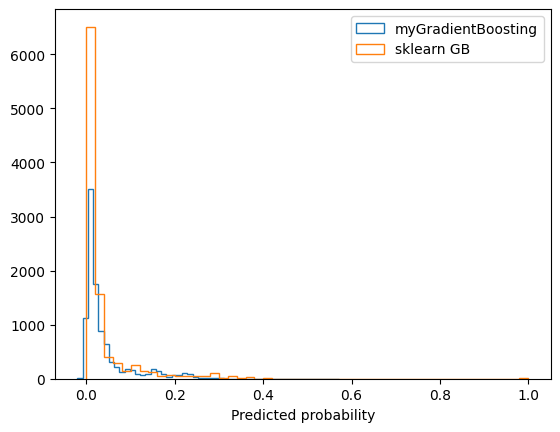

In [72]:
plt.figure()                                                                                                                       
plt.hist(gb_preds, bins=50, histtype='step', label='myGradientBoosting')                                                           
                                                                                                                                     
gb_sklearn.fit(X_train, y_train)                                                                                                   
sklearn_preds = gb_sklearn.predict_proba(test_data)[:, 1]                                                                          
plt.hist(sklearn_preds, bins=50, histtype='step', label='sklearn GB')                                                              
plt.legend()                                                                                                                       
plt.xlabel('Predicted probability')
plt.show()

In [73]:
# Key differences: 
# 1. loss function
# - we use MSE (Brier score) on raw 0/1 labels.
# - sklearn uses log-loss (cross-entropy) - proper loss classifictation that penalises confident wrong predictions much more heavily. 
# 2. output transformation
# - we sum raw regression outputs directly — these can go below 0 or above 1, producing invalid "probabilities."
# - Sklearn applies a sigmoid/log-odds transform to keep outputs in [0, 1].                                           
# 3. gradient
# - our MSE residuals are a simpler but less effective approach for classification
# - log-loss > sklearn will compute a different gradient at each step.